# Ejercicios en clase 24/10/25

In [ ]:
#Ejercicio 1
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 1 Descargar datos históricos
btc = yf.download("BTC-USD", start="2023-01-01", end="2025-01-01")

# 2 Calcular rendimientos y variable objetivo

btc["Rendimiento"] = np.log(btc["Close"] / btc["Close"].shift(1))
btc["Rend_prev"] = btc["Rendimiento"].shift(1)
btc["Sube"] = np.where(btc["Rendimiento"] > 0, 1, 0)
btc = btc.dropna()

# 3 Definir variables
X = btc[["Rend_prev", "Volume"]]
y = btc["Sube"]

# 4 División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5 Modelo
modelo = LogisticRegression(max_iter=500, class_weight='balanced')
modelo.fit(X_train, y_train)

# 6 Predicciones y evaluación
y_pred = modelo.predict(X_test)
print("Precisión:", round(accuracy_score(y_test, y_pred), 3))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

#¿Qué porcentaje de aciertos obtiene el modelo?
#54.1%

#¿Predice bien los días de subida y bajada o se sesga hacia una sola clase?
#Esta completamente sesgado hacia una clase (1), la cual es la que predice siempre.

#¿Cómo podrías mejorar el modelo agregando nuevas variables (por ejemplo, medias móviles)?
#Se podrian agregar medias moviles para capturar tendencias a corto y largo plazo, desviacion estandar de los ultimos dias para medir volatilidad,

C:\Users\mateo\AppData\Local\Temp\ipykernel_2104\3922103555.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Precisión: 0.541

Matriz de confusión:
 [[ 0 67]
 [ 0 79]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        67
           1       0.54      1.00      0.70        79

    accuracy                           0.54       146
   macro avg       0.27      0.50      0.35       146
weighted avg       0.29      0.54      0.38       146




c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

Umbral: 0.6
Precisión: 0.438

Matriz de confusión:
 [[63  4]
 [78  1]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.45      0.94      0.61        67
           1       0.20      0.01      0.02        79

    accuracy                           0.44       146
   macro avg       0.32      0.48      0.31       146
weighted avg       0.31      0.44      0.29       146



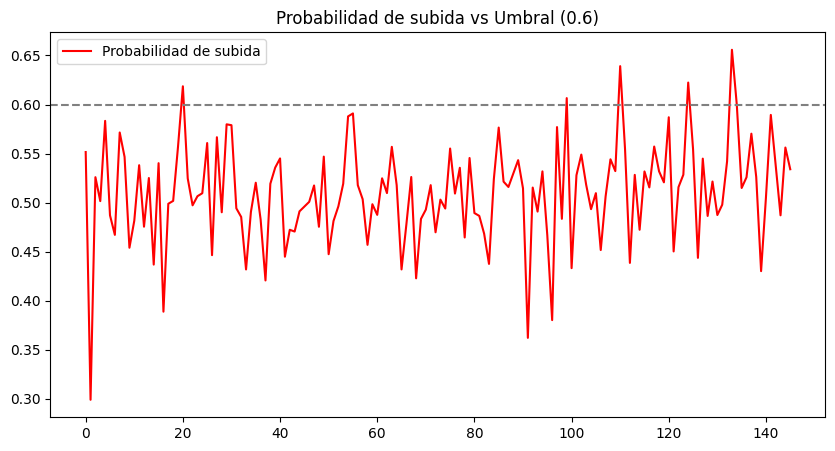

In [ ]:
#Ejercicio 2
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1 Escalar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2 Reentrenar el modelo
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)
modelo = LogisticRegression(class_weight='balanced', max_iter=500)
modelo.fit(X_train, y_train)

# 3 Probabilidades de subida
prob = modelo.predict_proba(X_test)[:, 1]

# 4 Cambiar umbral
umbral = 0.6  # ajusta entre 0.4 y 0.7
y_pred = (prob >= umbral).astype(int)

# 5 Evaluar
print("Umbral:", umbral)
print("Precisión:", round(accuracy_score(y_test, y_pred), 3))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# 6 Gráfica de probabilidades
plt.figure(figsize=(10,5))
plt.plot(prob, label="Probabilidad de subida", color="red")
plt.axhline(y=umbral, color="gray", linestyle="--")
plt.title(f"Probabilidad de subida vs Umbral ({umbral})")
plt.legend()
plt.show()

#¿Qué ocurre con la cantidad de falsos positivos y falsos negativos cuando cambias el umbral?
# La precisión ha disminuido al agregar el umbral, sigue habiendo falsos negativos y positivos pero por lo menos ya percibe la clase 0.

#¿Qué umbral te parece más apropiado para minimizar el riesgo de inversión?
# Un umbral mas elevado es mejor debido a su exigencia para considerar una predicción como subida, minimizando el riesgo de inversión,
# no obstante esto aumenta los falsos negativos.

#¿Qué representa visualmente la línea gris en la gráfica?
# El umbral

C:\Users\mateo\AppData\Local\Temp\ipykernel_2104\1628702476.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


SVR lineal - R²: 0.9713977009529093
Regresión lineal - R²: 0.9714334535302821


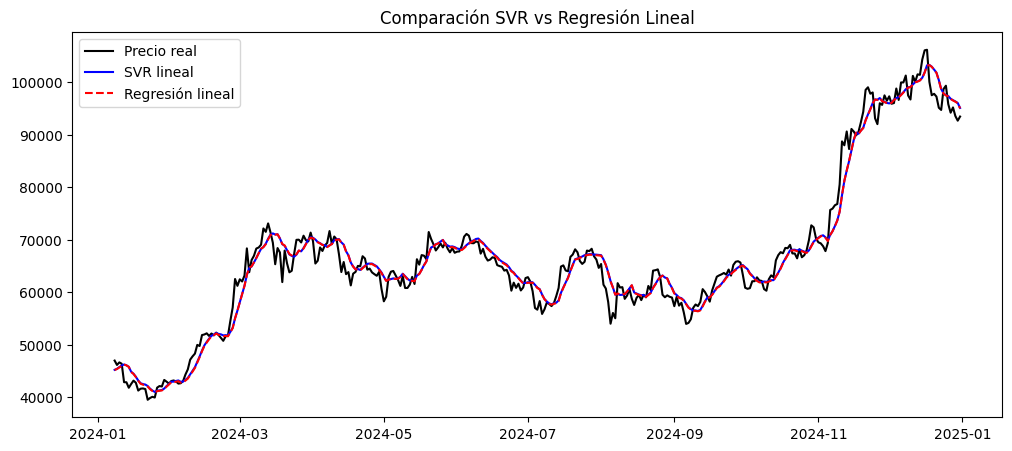

In [3]:
#EJERCICIO SVR

import pandas as pd

import numpy as np

import yfinance as yf

from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

 

# 1 Descargar precios de una acción o criptomoneda

btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")

# 2 Calcular variables

btc["Rendimiento"] = np.log(btc["Close"] / btc["Close"].shift(1))

btc["MA7"] = btc["Close"].rolling(7).mean()

btc["Volatilidad"] = btc["Rendimiento"].rolling(7).std()

btc = btc.dropna()

 

# 3 Variables predictoras y objetivo

X = btc[["MA7", "Volatilidad"]]

y = btc["Close"]

 

# 4 Escalar

scaler_X, scaler_y = StandardScaler(), StandardScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

 

# 5 Modelos

svr_linear = SVR(kernel='linear', C=100)

svr_linear.fit(X_scaled, y_scaled)

lr = LinearRegression()

lr.fit(X_scaled, y_scaled)

# 6 Predicción

y_pred_svr = scaler_y.inverse_transform(svr_linear.predict(X_scaled).reshape(-1, 1))

y_pred_lr = scaler_y.inverse_transform(lr.predict(X_scaled).reshape(-1, 1))

 

# 7 Evaluación

print("SVR lineal - R²:", r2_score(y, y_pred_svr))

print("Regresión lineal - R²:", r2_score(y, y_pred_lr))

 

# 8 Gráfico comparativo

plt.figure(figsize=(12,5))

plt.plot(btc.index, y, label="Precio real", color="black")

plt.plot(btc.index, y_pred_svr, label="SVR lineal", color="blue")

plt.plot(btc.index, y_pred_lr, label="Regresión lineal", color="red", linestyle="--")

plt.title("Comparación SVR vs Regresión Lineal")

plt.legend()

plt.show()

 

C:\Users\mateo\AppData\Local\Temp\ipykernel_2104\4247232059.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


RMSE: 2247.69
R²: 0.9759


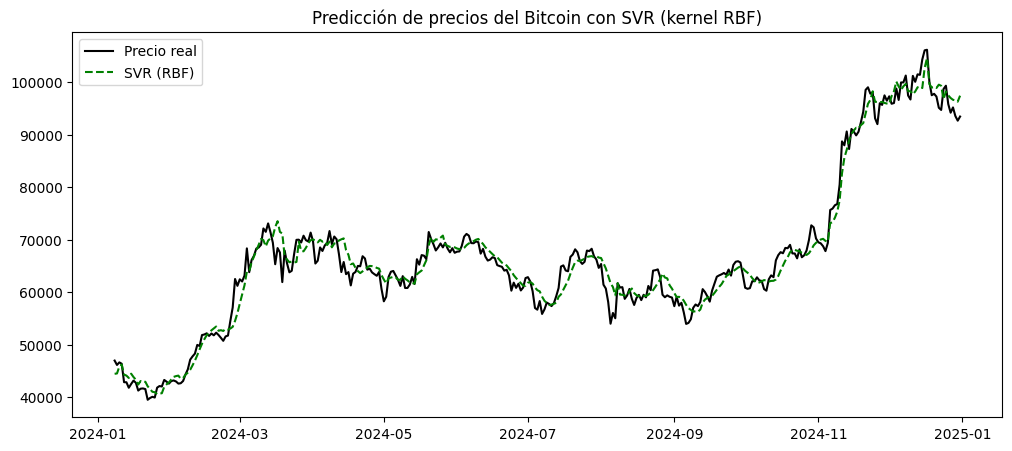

In [4]:
#EJERCICIO PREDICCION NO LINEAL CON SVR

import pandas as pd

import numpy as np

import yfinance as yf

from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

 

# 1 Descargar precios de una acción o criptomoneda

btc = yf.download("BTC-USD", start="2024-01-01", end="2025-01-01")

# 2 Calcular variables

btc["Rendimiento"] = np.log(btc["Close"] / btc["Close"].shift(1))

btc["MA7"] = btc["Close"].rolling(7).mean()

btc["Volatilidad"] = btc["Rendimiento"].rolling(7).std()

btc = btc.dropna()

 

# 3 Variables predictoras y objetivo

X = btc[["MA7", "Volatilidad"]]

y = btc["Close"]

 

# 4 Escalar

scaler_X, scaler_y = StandardScaler(), StandardScaler()

X_scaled = scaler_X.fit_transform(X)

y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()


# 2 Crear y entrenar modelo con kernel RBF

modelo = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

modelo.fit(X_scaled, y_scaled)

 

# 3 Predicción y evaluación

y_pred_scaled = modelo.predict(X_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

 

# 4 Métricas

rmse = np.sqrt(mean_squared_error(y, y_pred))

r2 = r2_score(y, y_pred)

print("RMSE:", round(rmse,2))

print("R²:", round(r2,4))

 

# 5 Gráfico

plt.figure(figsize=(12,5))

plt.plot(btc.index, y, label="Precio real", color="black")

plt.plot(btc.index, y_pred, label="SVR (RBF)", color="green", linestyle="--")

plt.title("Predicción de precios del Bitcoin con SVR (kernel RBF)")

plt.legend()

plt.show()